# Traffic forecasting 

## 1.Introduction

### 1.1 Problem Statement

### 1.2 Data

In [115]:
# import
import os
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from meteostat import Point, Hourly

from sklearn.impute import KNNImputer

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [2]:
# Traffic data

In [3]:
# weather data
start = datetime(2021, 1, 1)
end = datetime(2024, 1, 1) # (2023, 12, 31) will only show the 0 o'clock
la = Point(34.01696352677399, -118.41688979588534)
weather = Hourly(la, start, end)

In [4]:
weather = weather.fetch()
weather

,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,
2021-01-01 00:00:00,17.8,0.0,30.0,NaN,NaN,350.0,24.1,NaN,1013.0,NaN,2.0
2021-01-01 01:00:00,16.7,-0.1,32.0,0.0,NaN,340.0,24.1,NaN,1013.1,NaN,2.0
2021-01-01 02:00:00,16.1,-0.6,32.0,0.0,NaN,330.0,25.9,NaN,1013.9,NaN,2.0
2021-01-01 03:00:00,16.1,-1.0,31.0,0.0,NaN,330.0,22.3,NaN,1014.0,NaN,2.0
2021-01-01 04:00:00,15.0,-1.6,32.0,0.0,NaN,320.0,20.5,NaN,1013.9,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 20:00:00,15.0,10.0,72.0,0.0,NaN,40.0,7.0,NaN,1020.0,NaN,3.0
2023-12-31 21:00:00,15.0,10.0,72.0,0.0,NaN,110.0,7.0,NaN,1019.0,NaN,3.0
2023-12-31 22:00:00,15.0,10.0,72.0,0.0,NaN,100.0,7.0,NaN,1018.0,NaN,3.0


In [5]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26281 entries, 2021-01-01 00:00:00 to 2024-01-01 00:00:00
Freq: h
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   temp    26281 non-null  float64
 1   dwpt    26281 non-null  float64
 2   rhum    26281 non-null  float64
 3   prcp    26280 non-null  float64
 4   snow    0 non-null      float64
 5   wdir    26281 non-null  float64
 6   wspd    26281 non-null  float64
 7   wpgt    0 non-null      float64
 8   pres    26281 non-null  float64
 9   tsun    0 non-null      float64
 10  coco    26101 non-null  float64
dtypes: float64(11)
memory usage: 2.4 MB


In [6]:
weather.isnull().sum()

temp        0
dwpt        0
rhum        0
prcp        1
snow    26281
wdir        0
wspd        0
wpgt    26281
pres        0
tsun    26281
coco      180
dtype: int64

In [7]:
weather.to_csv('../data/weather-21-23.csv')

Meteorological Parameters ---- modify the no use paras
| Code | Meaning                 |
|------|-------------------------|
| TEMP | Air Temperature         |
| TAVG | Average Temperature     |
| TMIN | Minimum Temperature     |
| TMAX | Maximum Temperature     |
| DWPT | Dew Point               |
| PRCP | Total Precipitation     |
| WDIR | Wind (From) Direction   |
| WSPD | Average Wind Speed      |
| WPGT | Wind Peak Gust          |
| RHUM | Relative Humidity       |
| PRES | Sea-Level Air Pressure  |
| SNOW | Snow Depth              |
| TSUN | Total Sunshine Duration |
| COCO | Weather Condition Code  |

Meteorological Data Units
| Parameter(s)               | Unit    |
|----------------------------|---------|
| Temperature                | °C      |
| Precipitation              | mm      |
| Sunshine Duration          | Minutes |
| Air Pressure               | hPa     |
| Wind Speed, Peak Wind Gust | km/h    |
| Wind Direction             | Degrees |
| Visibility, Cloud Height   | m       |
| Relative Humidity          | %       |

Weather Condition Codes
| Code | Weather Condition   |
|------|---------------------|
| 1    | Clear               |
| 2    | Fair                |
| 3    | Cloudy              |
| 4    | Overcast            |
| 5    | Fog                 |
| 6    | Freezing Fog        |
| 7    | Light Rain          |
| 8    | Rain                |
| 9    | Heavy Rain          |
| 10   | Freezing Rain       |
| 11   | Heavy Freezing Rain |
| 12   | Sleet               |
| 13   | Heavy Sleet         |
| 14   | Light Snowfall      |
| 15   | Snowfall            |
| 16   | Heavy Snowfall      |
| 17   | Rain Shower         |
| 18   | Heavy Rain Shower   |
| 19   | Sleet Shower        |
| 20   | Heavy Sleet Shower  |
| 21   | Snow Shower         |
| 22   | Heavy Snow Shower   |
| 23   | Lightning           |
| 24   | Hail                |
| 25   | Thunderstorm        |
| 26   | Heavy Thunderstorm  |
| 27   | Storm               |

## 2. Data Cleaning

These three columns are completely missing.
* snow: It almost never snows in Southern California. 
* wpgt: Wind Peak Gust is for daily weather data.
* tsun: Total Sunshine Duration is for daily weather data.

In [8]:
weather = weather.drop(columns=['snow', 'wpgt', 'tsun'])

In [9]:
weather.tail()

,temp,dwpt,rhum,prcp,wdir,wspd,pres,coco
time,,,,,,,,
2023-12-31 20:00:00,15.0,10.0,72.0,0.0,40.0,7.0,1020.0,3.0
2023-12-31 21:00:00,15.0,10.0,72.0,0.0,110.0,7.0,1019.0,3.0
2023-12-31 22:00:00,15.0,10.0,72.0,0.0,100.0,7.0,1018.0,3.0
2023-12-31 23:00:00,15.0,10.0,72.0,0.0,40.0,9.0,1017.0,3.0
2024-01-01 00:00:00,15.0,9.4,69.0,0.0,103.0,13.0,1018.0,3.0


In [10]:
# drop the last row for 2024-1-1
weather = weather.drop(weather.index[-1])

In [11]:
df1 = pd.read_excel('../data/traffic-data/2021-01-flow.xlsx', index_col = 'Hour',parse_dates = True)
# df1.index = df1.index.strftime('%Y-%m-%d %H')
df1.head(2)

,771826-ML,717696-ML,718219-ML,717701-ML,717703-ML,718227-ML,717706-ML,717709-ML,716632-ML,771845-ML,...,717823-ML,767367-ML,717825-ML,717827-ML,771808-ML,771767-ML,772011-ML,772024-ML,# Lane Points,% Observed
Hour,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,690,846,869,1056,1125,1206,1190,1081,1136,1291,...,1072,1407,1142,1107,2530,3291,675,743,5652,68.135173
2021-01-01 01:00:00,793,880,929,1117,1117,1166,1144,1075,1091,1291,...,1151,1445,1190,1140,2655,3487,733,801,5652,68.046709


In [12]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 744 entries, 2021-01-01 00:00:00 to 2021-01-31 23:00:00
Columns: 107 entries, 771826-ML to % Observed
dtypes: float64(1), int64(106)
memory usage: 627.8 KB


In [13]:
df1.drop(df1.columns[-2:], axis=1, inplace=True)

In [14]:
df1.head(2)

,771826-ML,717696-ML,718219-ML,717701-ML,717703-ML,718227-ML,717706-ML,717709-ML,716632-ML,771845-ML,...,767351-ML,717819-ML,717823-ML,767367-ML,717825-ML,717827-ML,771808-ML,771767-ML,772011-ML,772024-ML
Hour,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,690,846,869,1056,1125,1206,1190,1081,1136,1291,...,1391,1147,1072,1407,1142,1107,2530,3291,675,743
2021-01-01 01:00:00,793,880,929,1117,1117,1166,1144,1075,1091,1291,...,1537,1248,1151,1445,1190,1140,2655,3487,733,801


In [15]:
df2 = pd.read_excel('../data/traffic-data/2021-02-flow.xlsx', index_col = 'Hour',parse_dates = True)
df2.drop(df2.columns[-2:], axis=1, inplace=True)
df2.head(2)

,771826-ML,717696-ML,718219-ML,717701-ML,717703-ML,718227-ML,717706-ML,717709-ML,716632-ML,771845-ML,...,767351-ML,717819-ML,717823-ML,767367-ML,717825-ML,717827-ML,771808-ML,771767-ML,772011-ML,772024-ML
Hour,,,,,,,,,,,,,,,,,,,,,
2021-02-01 00:00:00,468,585,576,736,787,867,1394,699,761,899,...,1268,878,839,1058,888,853,1902,2294,491,422
2021-02-01 01:00:00,322,389,360,511,658,665,979,467,473,684,...,850,599,580,661,530,562,1438,1796,343,289


In [16]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 672 entries, 2021-02-01 00:00:00 to 2021-02-28 23:00:00
Columns: 105 entries, 771826-ML to 772024-ML
dtypes: int64(105)
memory usage: 556.5 KB


In [17]:
(df1.columns == df2.columns).all()

True

In [18]:
files = os.listdir('../data/traffic-data/')
files.sort()

In [19]:
def dataframe_process(folder):
    '''
    return
    '''
    df_list = []
    
    for file in folder:
        file_path = f'../data/traffic-data/{file}'
        df = pd.read_excel(file_path, index_col = 'Hour', parse_dates = True)
        df.drop(df.columns[-2:], axis=1, inplace=True)
        df_list.append(df)
    
    # df_1_columns = df_list[0].columns
    # for df in df_list[1:]:
    #     if not (df.columns == df_1_columns).all():
    #         print('Columns in dataframes are not the same')
    #         return None

    df_combined = pd.concat(df_list)
    return df_combined

In [20]:
df = dataframe_process(files)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26206 entries, 2021-01-01 00:00:00 to 2023-12-31 23:00:00
Columns: 105 entries, 771826-ML to 772024-ML
dtypes: int64(105)
memory usage: 21.2 MB


In [21]:
df.isnull().sum().sum()

0

In [22]:
df.index[1:]

DatetimeIndex(['2021-01-01 01:00:00', '2021-01-01 02:00:00',
               '2021-01-01 03:00:00', '2021-01-01 04:00:00',
               '2021-01-01 05:00:00', '2021-01-01 06:00:00',
               '2021-01-01 07:00:00', '2021-01-01 08:00:00',
               '2021-01-01 09:00:00', '2021-01-01 10:00:00',
               ...
               '2023-12-31 14:00:00', '2023-12-31 15:00:00',
               '2023-12-31 16:00:00', '2023-12-31 17:00:00',
               '2023-12-31 18:00:00', '2023-12-31 19:00:00',
               '2023-12-31 20:00:00', '2023-12-31 21:00:00',
               '2023-12-31 22:00:00', '2023-12-31 23:00:00'],
              dtype='datetime64[ns]', name='Hour', length=26205, freq=None)

In [23]:
df.index[:-1]

DatetimeIndex(['2021-01-01 00:00:00', '2021-01-01 01:00:00',
               '2021-01-01 02:00:00', '2021-01-01 03:00:00',
               '2021-01-01 04:00:00', '2021-01-01 05:00:00',
               '2021-01-01 06:00:00', '2021-01-01 07:00:00',
               '2021-01-01 08:00:00', '2021-01-01 09:00:00',
               ...
               '2023-12-31 13:00:00', '2023-12-31 14:00:00',
               '2023-12-31 15:00:00', '2023-12-31 16:00:00',
               '2023-12-31 17:00:00', '2023-12-31 18:00:00',
               '2023-12-31 19:00:00', '2023-12-31 20:00:00',
               '2023-12-31 21:00:00', '2023-12-31 22:00:00'],
              dtype='datetime64[ns]', name='Hour', length=26205, freq=None)

In [24]:
# Calculate the time difference between timestamps
time_diffs = df.index[1:] - df.index[:-1] # could use shift?

print(time_diffs.value_counts())

Hour
0 days 01:00:00    26201
0 days 02:00:00        3
3 days 00:00:00        1
Name: count, dtype: int64


In [25]:
# full range of timestamps
full_index = pd.date_range(start='2021-01-01 00:00:00', end='2023-12-31 23:00:00', freq='h')

missing_timestamps = full_index.difference(df.index)

print('Number of missing timestamps:', len(missing_timestamps))
print('Missing timestamps:', missing_timestamps)

Number of missing timestamps: 74
Missing timestamps: DatetimeIndex(['2021-03-14 02:00:00', '2022-03-13 02:00:00',
               '2023-03-12 02:00:00', '2023-12-19 01:00:00',
               '2023-12-19 02:00:00', '2023-12-19 03:00:00',
               '2023-12-19 04:00:00', '2023-12-19 05:00:00',
               '2023-12-19 06:00:00', '2023-12-19 07:00:00',
               '2023-12-19 08:00:00', '2023-12-19 09:00:00',
               '2023-12-19 10:00:00', '2023-12-19 11:00:00',
               '2023-12-19 12:00:00', '2023-12-19 13:00:00',
               '2023-12-19 14:00:00', '2023-12-19 15:00:00',
               '2023-12-19 16:00:00', '2023-12-19 17:00:00',
               '2023-12-19 18:00:00', '2023-12-19 19:00:00',
               '2023-12-19 20:00:00', '2023-12-19 21:00:00',
               '2023-12-19 22:00:00', '2023-12-19 23:00:00',
               '2023-12-20 00:00:00', '2023-12-20 01:00:00',
               '2023-12-20 02:00:00', '2023-12-20 03:00:00',
               '2023-12-20 04:00

In [26]:
# rename index column to time before merge
df.rename_axis('time', inplace=True)

In [27]:
df_combined = pd.merge(weather, df, how='left', on='time')

In [28]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26280 entries, 2021-01-01 00:00:00 to 2023-12-31 23:00:00
Columns: 113 entries, temp to 772024-ML
dtypes: float64(113)
memory usage: 22.9 MB


In [29]:
df_combined.isnull().sum()

temp          0
dwpt          0
rhum          0
prcp          1
wdir          0
             ..
717827-ML    74
771808-ML    74
771767-ML    74
772011-ML    74
772024-ML    74
Length: 113, dtype: int64

In [63]:
df_combined

,temp,dwpt,rhum,prcp,wdir,wspd,pres,coco,771826-ML,717696-ML,...,767351-ML,717819-ML,717823-ML,767367-ML,717825-ML,717827-ML,771808-ML,771767-ML,772011-ML,772024-ML
time,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,17.8,0.0,30.0,NaN,350.0,24.1,1013.0,2.0,690.0,846.0,...,1391.0,1147.0,1072.0,1407.0,1142.0,1107.0,2530.0,3291.0,675.0,743.0
2021-01-01 01:00:00,16.7,-0.1,32.0,0.0,340.0,24.1,1013.1,2.0,793.0,880.0,...,1537.0,1248.0,1151.0,1445.0,1190.0,1140.0,2655.0,3487.0,733.0,801.0
2021-01-01 02:00:00,16.1,-0.6,32.0,0.0,330.0,25.9,1013.9,2.0,463.0,609.0,...,1164.0,873.0,808.0,1037.0,855.0,823.0,2238.0,2938.0,449.0,541.0
2021-01-01 03:00:00,16.1,-1.0,31.0,0.0,330.0,22.3,1014.0,2.0,347.0,403.0,...,862.0,585.0,541.0,642.0,544.0,551.0,1813.0,2506.0,327.0,408.0
2021-01-01 04:00:00,15.0,-1.6,32.0,0.0,320.0,20.5,1013.9,1.0,388.0,473.0,...,753.0,501.0,503.0,561.0,476.0,448.0,1711.0,2557.0,286.0,454.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,15.0,9.4,69.0,0.0,86.0,6.0,1021.0,3.0,5138.0,5138.0,...,3811.0,3646.0,3561.0,3952.0,5138.0,5025.0,4715.0,5658.0,2289.0,2892.0
2023-12-31 20:00:00,15.0,10.0,72.0,0.0,40.0,7.0,1020.0,3.0,5011.0,5011.0,...,3331.0,3203.0,3011.0,3567.0,5011.0,4586.0,4085.0,5097.0,1814.0,2424.0
2023-12-31 21:00:00,15.0,10.0,72.0,0.0,110.0,7.0,1019.0,3.0,4732.0,4732.0,...,2939.0,2763.0,2546.0,3139.0,4732.0,3677.0,3226.0,4128.0,1460.0,1922.0


In [ ]:
# check dynamic time warping for time series impute

In [73]:
knn_impute = KNNImputer(weights='distance')
df_combined_knn_imputed = knn_impute.fit_transform(df_combined)
df_combined_knn_imputed = pd.DataFrame(df_combined_knn_imputed, columns=df_combined.columns)

In [74]:
df_combined_knn_imputed.head()

,temp,dwpt,rhum,prcp,wdir,wspd,pres,coco,771826-ML,717696-ML,...,767351-ML,717819-ML,717823-ML,767367-ML,717825-ML,717827-ML,771808-ML,771767-ML,772011-ML,772024-ML
0,17.8,0.0,30.0,0.0,350.0,24.1,1013.0,2.0,690.0,846.0,...,1391.0,1147.0,1072.0,1407.0,1142.0,1107.0,2530.0,3291.0,675.0,743.0
1,16.7,-0.1,32.0,0.0,340.0,24.1,1013.1,2.0,793.0,880.0,...,1537.0,1248.0,1151.0,1445.0,1190.0,1140.0,2655.0,3487.0,733.0,801.0
2,16.1,-0.6,32.0,0.0,330.0,25.9,1013.9,2.0,463.0,609.0,...,1164.0,873.0,808.0,1037.0,855.0,823.0,2238.0,2938.0,449.0,541.0
3,16.1,-1.0,31.0,0.0,330.0,22.3,1014.0,2.0,347.0,403.0,...,862.0,585.0,541.0,642.0,544.0,551.0,1813.0,2506.0,327.0,408.0
4,15.0,-1.6,32.0,0.0,320.0,20.5,1013.9,1.0,388.0,473.0,...,753.0,501.0,503.0,561.0,476.0,448.0,1711.0,2557.0,286.0,454.0


In [75]:
# datetime index disappear after imputation 
df_combined_knn_imputed.index = df_combined.index
df_combined_knn_imputed.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26280 entries, 2021-01-01 00:00:00 to 2023-12-31 23:00:00
Columns: 113 entries, temp to 772024-ML
dtypes: float64(113)
memory usage: 22.9 MB


In [76]:
df_combined_knn_imputed.isnull().sum()

temp         0
dwpt         0
rhum         0
prcp         0
wdir         0
            ..
717827-ML    0
771808-ML    0
771767-ML    0
772011-ML    0
772024-ML    0
Length: 113, dtype: int64

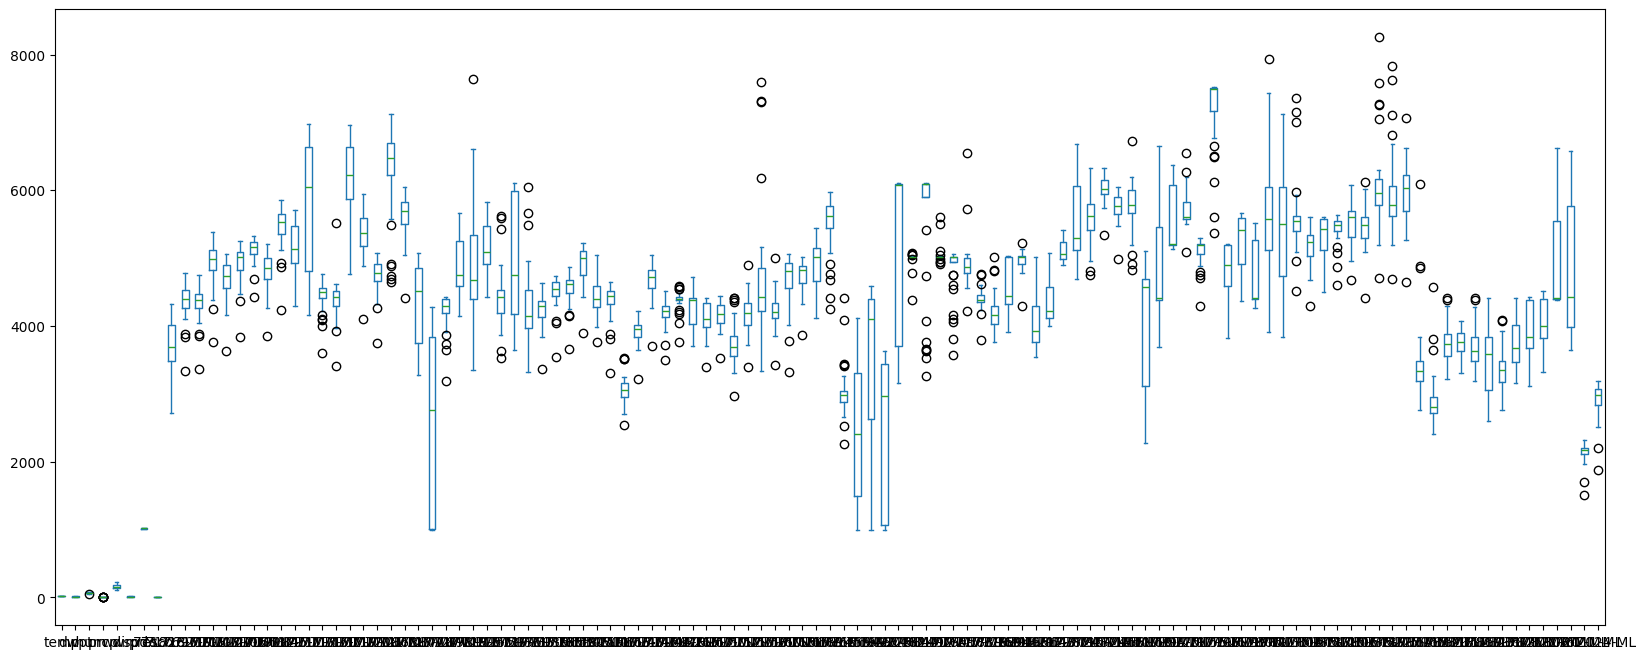

In [125]:
df_combined_knn_imputed.resample('ME').mean().plot(kind='box',figsize=(20,8));

In [123]:
# df_combined_knn_imputed.to_csv('../data/cleared-combine-21-23.csv')

## 3. Exploratory data analysis

In [31]:
# weather = pd.read_csv('../data/weather-21-23.csv')

In [32]:
weather.columns

Index(['temp', 'dwpt', 'rhum', 'prcp', 'wdir', 'wspd', 'pres', 'coco'], dtype='object')

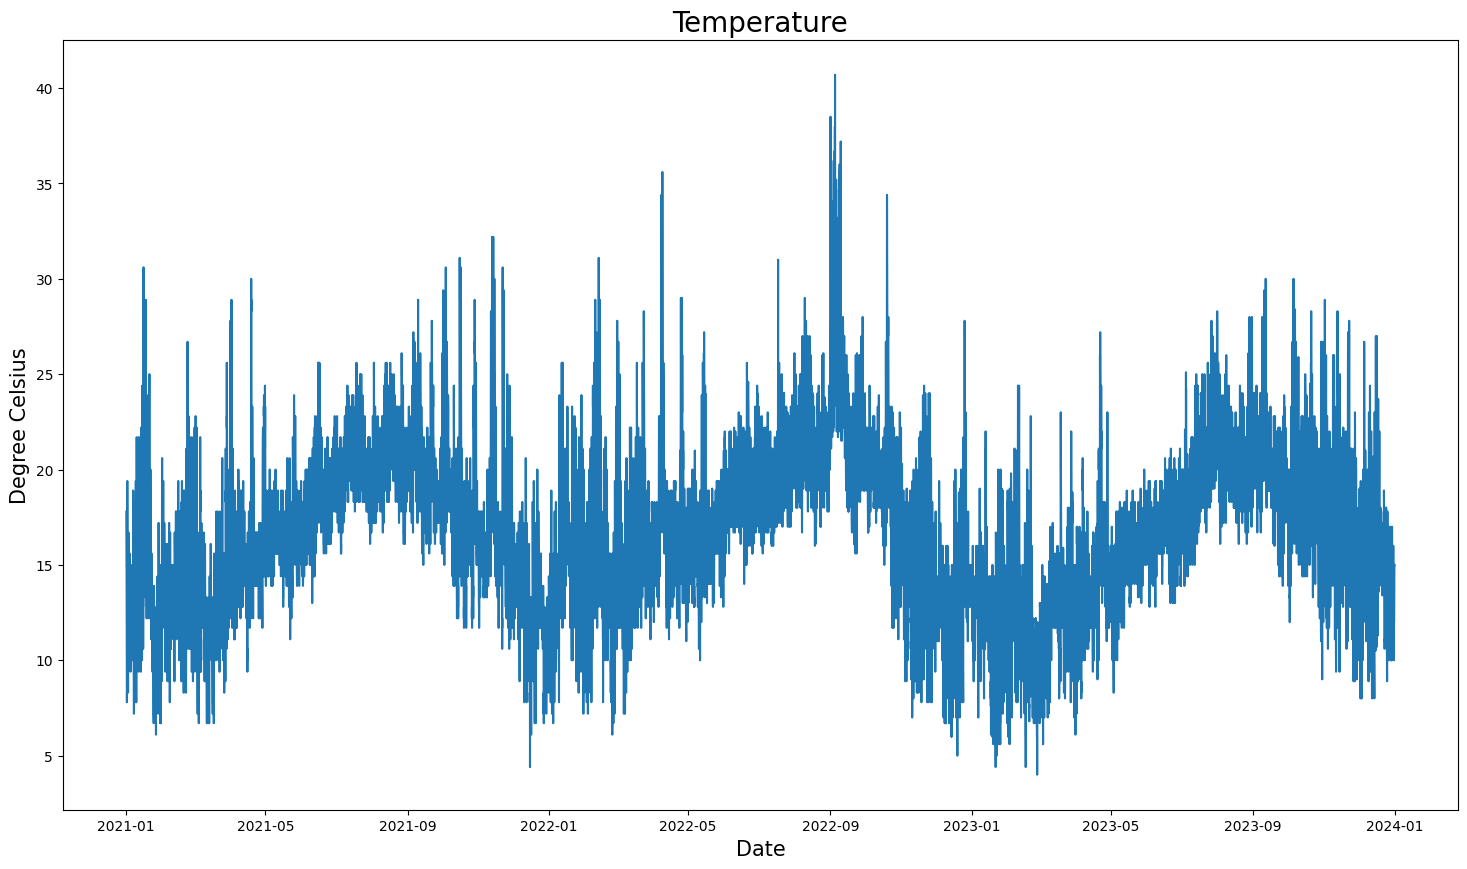

In [33]:
plt.figure(figsize = (18,10))
plt.plot(weather['temp'])

plt.title('Temperature', size = 20)
plt.xlabel('Date', size = 15)
plt.ylabel('Degree Celsius', size = 15);

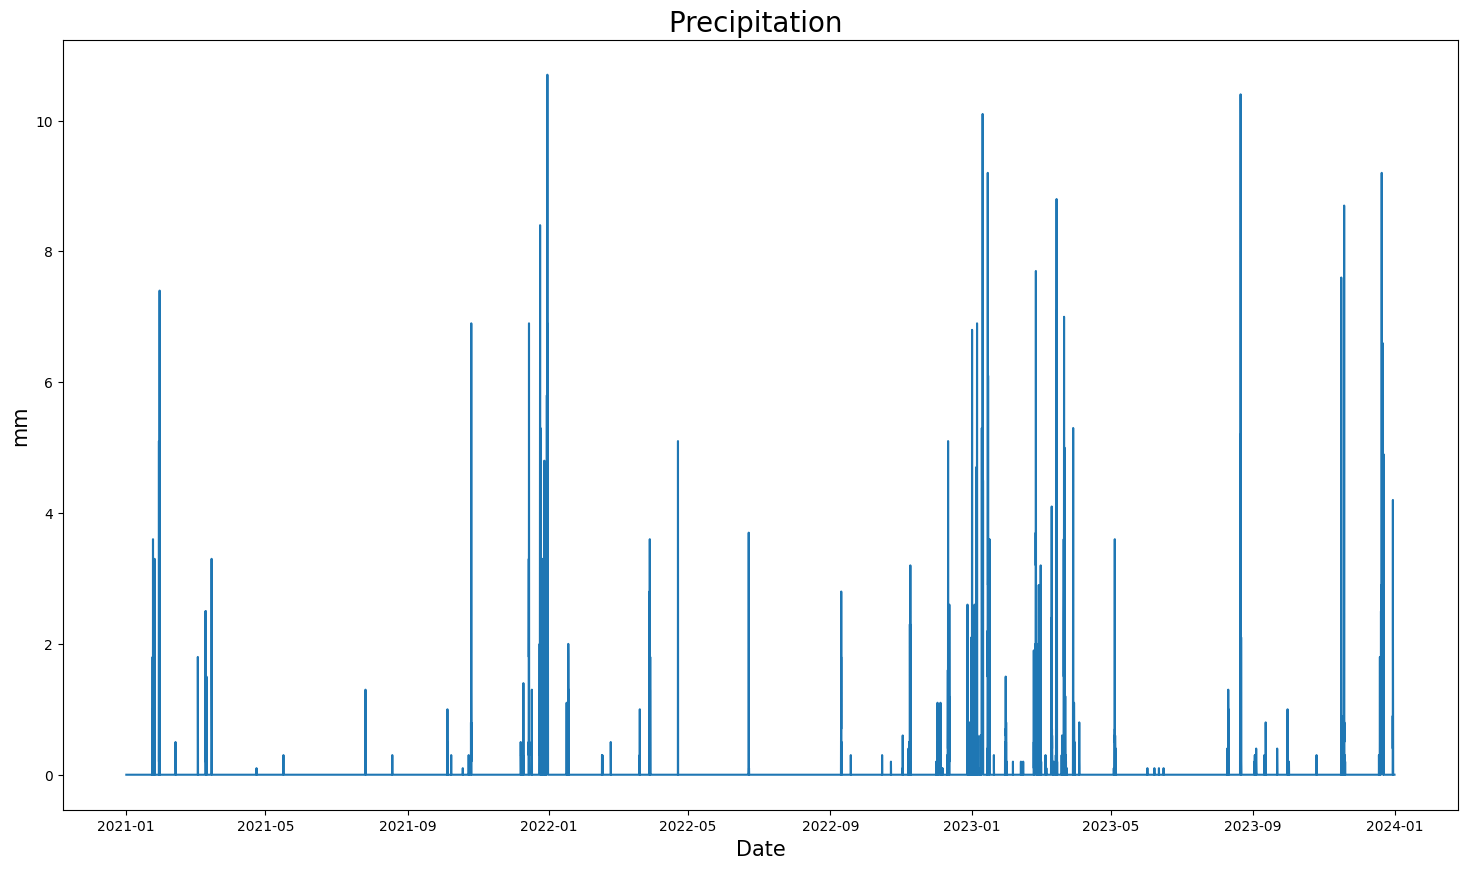

In [34]:
plt.figure(figsize = (18,10))
plt.plot(weather['prcp'])

plt.title('Precipitation', size = 20)
plt.xlabel('Date', size = 15)
plt.ylabel('mm', size = 15);

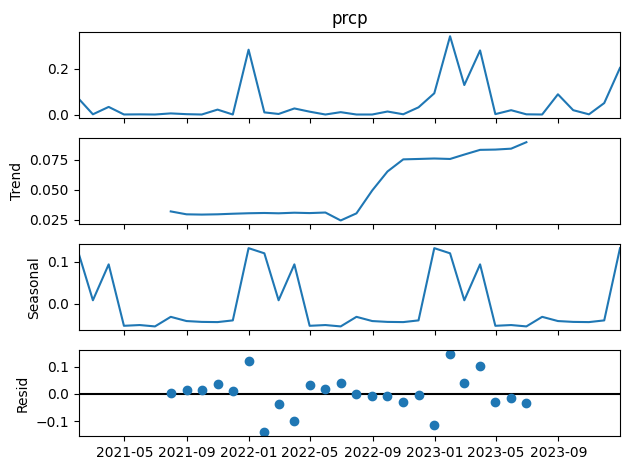

In [90]:
montly_prcp = weather['prcp'].resample('ME').mean()
decomp = seasonal_decompose(montly_prcp)
decomp.plot();

In [35]:
weather['coco'].value_counts(normalize=True)

coco
1.0     0.282797
2.0     0.273755
3.0     0.249195
5.0     0.124943
4.0     0.031149
7.0     0.012720
9.0     0.011801
8.0     0.010038
17.0    0.003142
18.0    0.000460
Name: proportion, dtype: float64

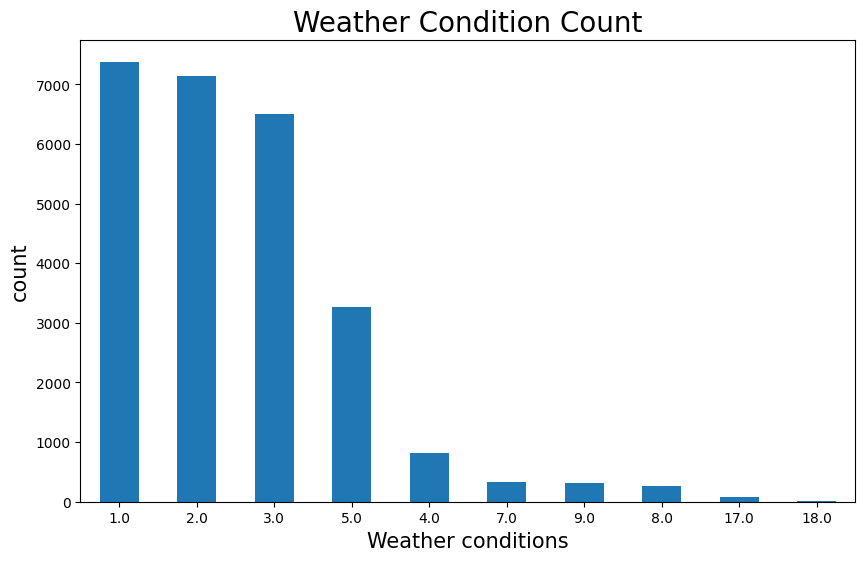

In [36]:
plt.figure(figsize = (10,6))
weather['coco'].value_counts().plot(kind='bar')

plt.title('Weather Condition Count', size = 20)
plt.xticks(rotation = 0)
plt.xlabel('Weather conditions', size = 15)
plt.ylabel('count', size = 15);

In [37]:
weather.describe()

,temp,dwpt,rhum,prcp,wdir,wspd,pres,coco
count,26280.000000,26280.000000,26280.000000,26279.000000,26280.000000,26280.000000,26280.000000,26100.000000
mean,16.715441,10.145335,69.027626,0.048971,160.761339,9.933387,1015.323702,2.664444
std,4.205331,6.234829,19.668428,0.411804,109.174497,7.117556,3.837212,1.849849
min,4.000000,-17.300000,6.000000,0.000000,0.000000,0.000000,996.800000,1.000000
25%,13.900000,7.300000,60.000000,0.000000,50.000000,5.400000,1012.800000,1.000000
50%,16.700000,11.700000,74.000000,0.000000,210.000000,9.400000,1015.000000,2.000000
75%,19.400000,15.000000,84.000000,0.000000,250.000000,14.800000,1017.800000,3.000000
max,40.700000,28.900000,100.000000,10.700000,360.000000,59.400000,1028.900000,18.000000


In [92]:
# choose station '717696-ML' to analyze 
station = df_combined_knn_imputed['717696-ML']

In [77]:
df_combined_knn_imputed['717696-ML'].describe()

count    26280.000000
mean      4357.402013
std       2305.426521
min         56.000000
25%       2060.000000
50%       5272.000000
75%       6385.000000
max       9000.000000
Name: 717696-ML, dtype: float64

### Seasonal decomposition

In [ ]:
# hourly

In [ ]:
# plt.figure(figsize = (18,10))
# plt.plot(df_combined_knn_imputed['717696-ML'])

# plt.title('Hourly Traffic Volume for Station 717696-ML', size = 20)
# plt.xlabel('Date', size = 15)
# plt.ylabel('Traffic count', size = 15);

In [ ]:
# decomp = seasonal_decompose(df_combined_knn_imputed['717696-ML'])
# decomp.plot();

In [82]:
# daily
day_sample = df_combined_knn_imputed['717696-ML'].resample('d').mean()

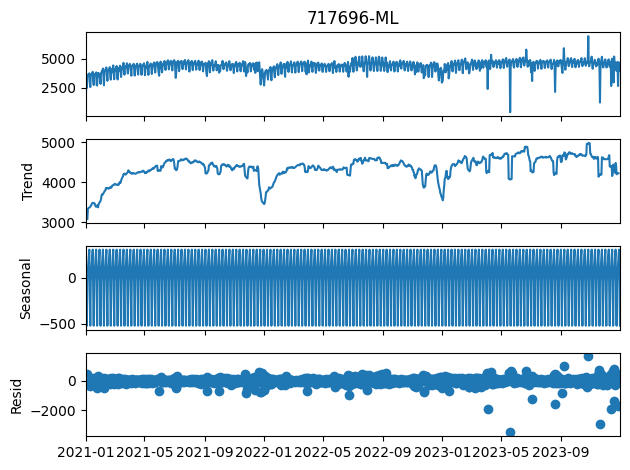

In [85]:
decomp = seasonal_decompose(day_sample)
decomp.plot();

In [87]:
# weekly
week_sample = df_combined_knn_imputed['717696-ML'].resample('W').mean()

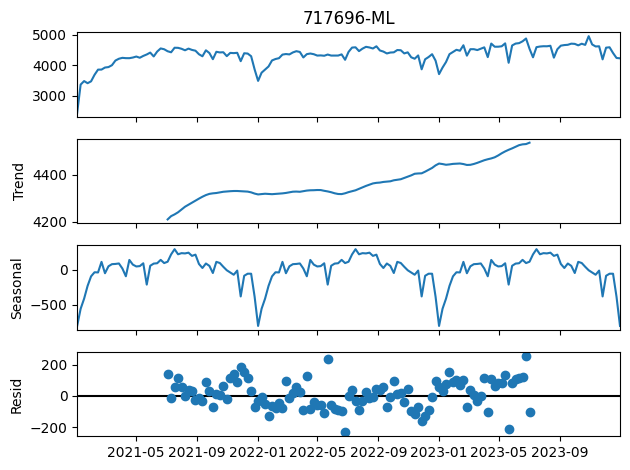

In [88]:
decomp = seasonal_decompose(week_sample)
decomp.plot();

In [80]:
# monthly
month_sample = df_combined_knn_imputed['717696-ML'].resample('ME').mean()

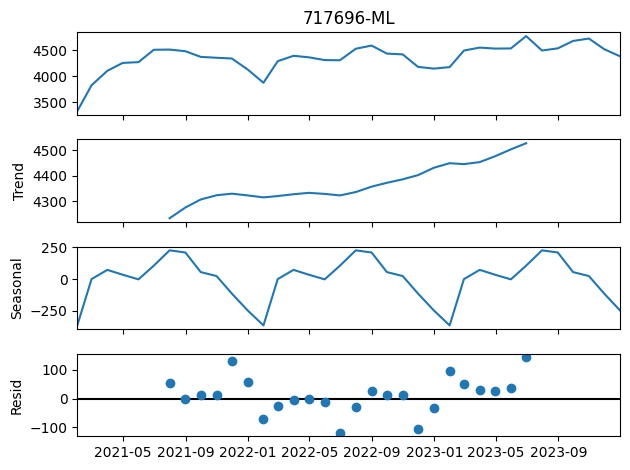

In [81]:
decomp = seasonal_decompose(month_sample)
decomp.plot();

### Correlation

In [122]:
df_combined_knn_imputed.corr().round(2)

,temp,dwpt,rhum,prcp,wdir,wspd,pres,coco,771826-ML,717696-ML,...,767351-ML,717819-ML,717823-ML,767367-ML,717825-ML,717827-ML,771808-ML,771767-ML,772011-ML,772024-ML
temp,1.00,0.40,-0.24,-0.10,0.26,0.21,-0.36,-0.12,-0.12,-0.13,...,0.00,0.01,0.02,-0.04,-0.05,-0.08,-0.07,-0.05,-0.11,-0.21
dwpt,0.40,1.00,0.76,0.02,0.10,-0.01,-0.55,0.18,-0.02,-0.02,...,-0.01,0.03,0.01,-0.03,-0.01,-0.04,-0.07,-0.06,-0.07,-0.06
rhum,-0.24,0.76,1.00,0.12,-0.10,-0.20,-0.34,0.31,0.08,0.08,...,-0.00,0.03,0.01,0.01,0.04,0.03,-0.01,-0.03,0.02,0.11
prcp,-0.10,0.02,0.12,1.00,-0.04,0.06,-0.08,0.38,-0.01,-0.02,...,-0.03,-0.04,-0.03,-0.03,0.00,0.02,-0.02,-0.05,-0.01,-0.02
wdir,0.26,0.10,-0.10,-0.04,1.00,0.60,-0.14,-0.02,-0.34,-0.35,...,-0.24,-0.21,-0.24,-0.25,-0.30,-0.30,-0.22,-0.16,-0.28,-0.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
717827-ML,-0.08,-0.04,0.03,0.02,-0.30,-0.28,0.07,0.11,0.91,0.91,...,0.91,0.87,0.91,0.89,0.97,1.00,0.82,0.71,0.85,0.77
771808-ML,-0.07,-0.07,-0.01,-0.02,-0.22,-0.18,0.12,0.07,0.80,0.83,...,0.80,0.80,0.82,0.79,0.82,0.82,1.00,0.93,0.82,0.77
771767-ML,-0.05,-0.06,-0.03,-0.05,-0.16,-0.13,0.10,0.04,0.69,0.72,...,0.75,0.77,0.76,0.76,0.72,0.71,0.93,1.00,0.76,0.68
772011-ML,-0.11,-0.07,0.02,-0.01,-0.28,-0.26,0.10,0.08,0.84,0.86,...,0.82,0.78,0.82,0.80,0.86,0.85,0.82,0.76,1.00,0.86


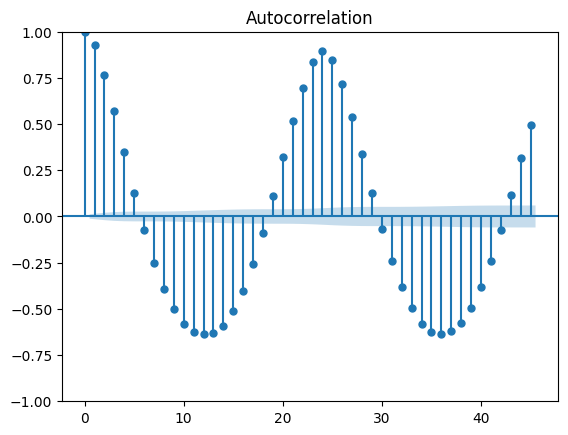

In [102]:
plot_acf(station);

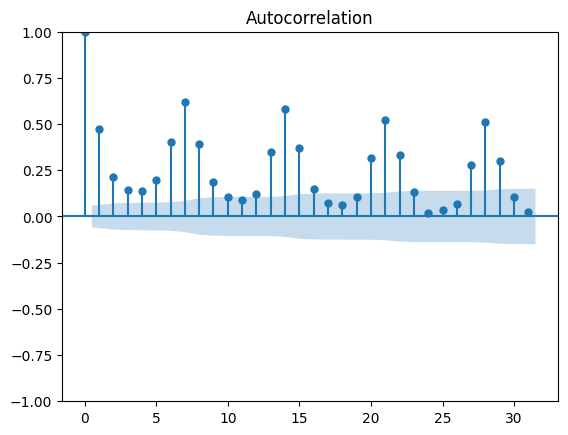

In [99]:
plot_acf(day_sample);

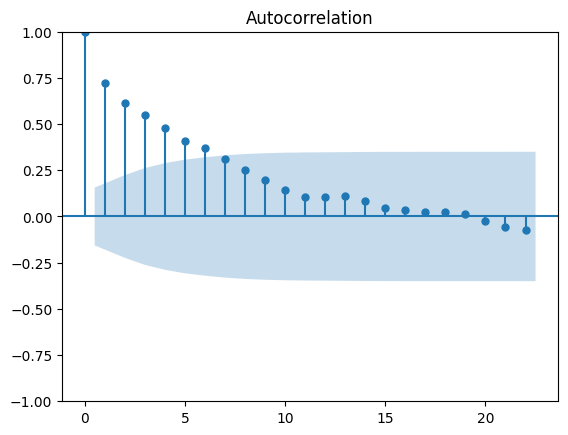

In [103]:
plot_acf(week_sample);

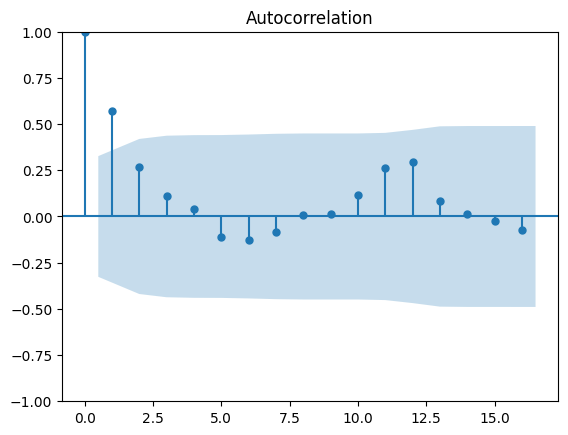

In [104]:
plot_acf(month_sample);

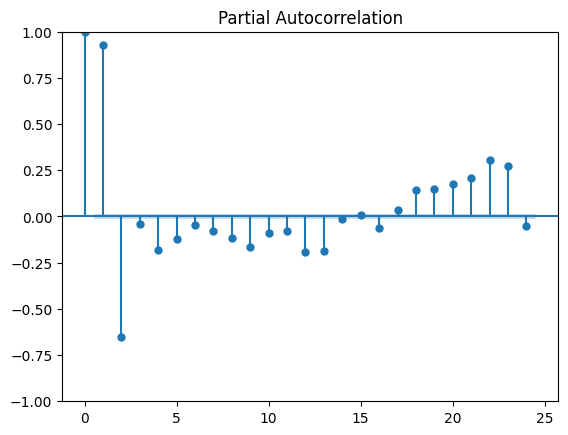

In [111]:
plot_pacf(station, lags=24);

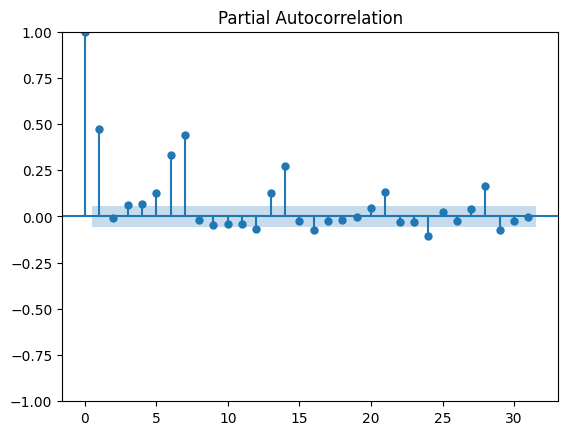

In [112]:
plot_pacf(day_sample, lags=31);

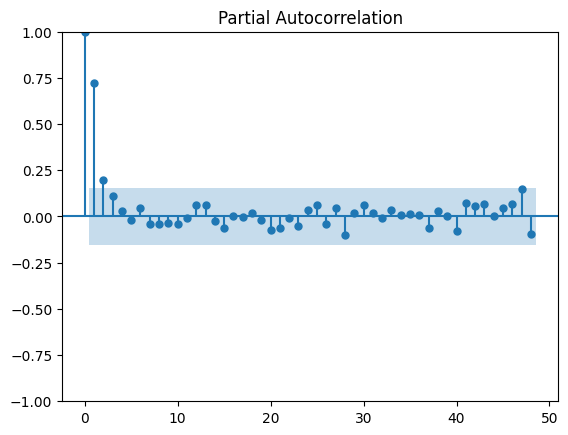

In [110]:
plot_pacf(week_sample, lags=48);

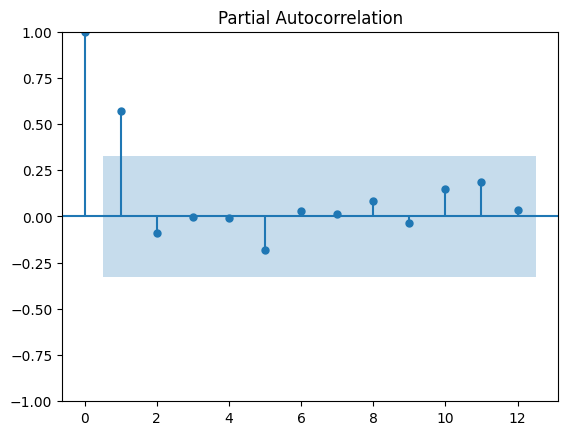

In [114]:
plot_pacf(month_sample, lags=12);

### Stationarity testing

In [116]:
adfuller(station)

(-15.715528079714685,
 1.3433124554037256e-28,
 49,
 26230,
 {'1%': -3.43059933054021,
  '5%': -2.861650196777599,
  '10%': -2.566828654483077},
 397636.13317596813)

* p-value is less than 0.05
* the hourly traffic is stationary

In [126]:
adfuller(day_sample)

(-4.0300216621388465,
 0.0012612155998900807,
 20,
 1074,
 {'1%': -3.4364533503600962,
  '5%': -2.864234857527328,
  '10%': -2.568204837482531},
 15432.366701063715)

In [127]:
adfuller(week_sample)

(-4.654932638003716,
 0.00010218158838197897,
 1,
 155,
 {'1%': -3.4732590518613002,
  '5%': -2.880374082105334,
  '10%': -2.5768120811654525},
 1849.6840727507758)

In [129]:
adfuller(month_sample)

(-0.5815957630654267,
 0.875086638302949,
 9,
 26,
 {'1%': -3.7112123008648155,
  '5%': -2.981246804733728,
  '10%': -2.6300945562130176},
 325.72418100634513)

monthly data is not stationary

In [131]:
adfuller(month_sample.diff().dropna())

(-3.553943874544289,
 0.006705083235057177,
 10,
 24,
 {'1%': -3.7377092158564813,
  '5%': -2.9922162731481485,
  '10%': -2.635746736111111},
 312.436293041356)

In [132]:
adfuller(month_sample.diff().diff().dropna())

(-4.094519872579437,
 0.0009889237870444193,
 10,
 23,
 {'1%': -3.7529275211638033,
  '5%': -2.998499866852963,
  '10%': -2.6389669754253307},
 307.77484255672493)